In [1]:
import os
from pathlib import Path
import numpy as np
from skimage import io, exposure
import pandas as pd
from sklearn.model_selection import train_test_split
# 5) Load MobileNetV3‐Small pretrained from PyTorch and adapt for binary classification
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.transforms import Normalize

import random
import matplotlib.pyplot as plt
from skimage.filters import sobel
from skimage.color import rgb2gray
from torchvision import transforms

import torch.nn.functional as F


from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from scipy.ndimage import gaussian_laplace







In [5]:


# Pull down pretrained MobileNetV3‐Small
model = models.mobilenet_v3_small(pretrained=True)

# Replace the classifier head for 2 classes
in_feats = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_feats, 2)

# (Later, after we add extra channels, you'll rewire the first conv to accept 5 inputs)

# --- a) Custom Dataset that reads your train/val CSVs -
class CSVImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.filepath).convert("RGB")
        label = int(row.label)
        if self.transform:
            img = self.transform(img)
        return img, label

# --- b) Transform to append LoG + Sobel as two extra channels ---
class AddEdgeLayers:
    def __call__(self, img_tensor):
        # img_tensor: Tensor[C=3, H, W], values [0,1]
        np_img = img_tensor.permute(1,2,0).numpy()           # H x W x 3
        gray   = rgb2gray(np_img)                            # H x W
        log    = gaussian_laplace(gray, sigma=1.0)           # H x W
        edge   = sobel(gray)                                 # H x W
        # normalize to [0,1]
        log  = (log  - log.min())  / (log.max()  - log.min()  + 1e-8)
        edge = (edge - edge.min()) / (edge.max() - edge.min() + 1e-8)
        # back to torch and concat
        log_t  = torch.from_numpy(log).unsqueeze(0).float()   # 1 x H x W
        edge_t = torch.from_numpy(edge).unsqueeze(0).float()  # 1 x H x W
        return torch.cat([img_tensor, log_t, edge_t], dim=0)  # 5 x H x W



class AddEdgeLayersTorch:
    def __call__(self, img_tensor):
        # img_tensor: Tensor[3, H, W] in [0,1]
        # 1) make a grayscale [1,1,H,W]
        r, g, b = img_tensor[0], img_tensor[1], img_tensor[2]
        gray = 0.2989*r + 0.5870*g + 0.1140*b
        gray = gray.unsqueeze(0).unsqueeze(0)  # 1×1×H×W

        # 2) define kernels
        sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],
                               dtype=torch.float32).view(1,1,3,3)
        sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],
                               dtype=torch.float32).view(1,1,3,3)
        laplace = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]],
                               dtype=torch.float32).view(1,1,3,3)

        # 3) convolve
        Gx  = F.conv2d(gray, sobel_x,   padding=1)  # 1×1×H×W
        Gy  = F.conv2d(gray, sobel_y,   padding=1)
        edge= torch.sqrt(Gx*Gx + Gy*Gy)             # Sobel magnitude

        log = F.conv2d(gray, laplace, padding=1)    # Laplacian ≈ LoG

        # 4) normalize each to [0,1]
        edge = (edge - edge.min())/(edge.max() - edge.min() + 1e-6)
        log  = (log  - log .min())/(log .max() - log .min()  + 1e-6)

        # 5) squeeze off the batch dims → [1,H,W], then cat
        edge = edge.squeeze(0)
        log  = log .squeeze(0)
        return torch.cat([img_tensor, edge, log], dim=0)  # [5,H,W]


C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Train test split

In [ ]:
# --- settings ---
BASE_DIR    = Path(r"images_for_modeling\forest_v_all")
DEFORESTED  = BASE_DIR / "deforested"
OUT_DIR     = BASE_DIR / "deforested_clahe"

CLIP_LIMIT = 0.01
NBINS      = 256

# create output directory if it doesn't exist
OUT_DIR.mkdir(exist_ok=True)

# 1) copy + CLAHE
for img_path in DEFORESTED.glob("*.png"):
    # load and normalize to [0,1]
    img = io.imread(str(img_path)).astype(np.float32) / 255.0
    clahe_img = np.zeros_like(img)

    # per-channel CLAHE
    for c in range(img.shape[2]):
        clahe_img[..., c] = exposure.equalize_adapthist(
            img[..., c],
            clip_limit=CLIP_LIMIT,
            nbins=NBINS
        )

    # scale back to [0,255]
    clahe_img = (clahe_img * 255).astype(np.uint8)

    # 2) skip images that are all white
    if np.all(clahe_img == 255):
        continue

    # save
    io.imsave(str(OUT_DIR / img_path.name), clahe_img)


In [46]:
for cls_name in class_map:
    cls_dir = BASE_DIR/cls_name
    if not cls_dir.exists():
        print(f"⚠️  Directory not found: {cls_dir}")

In [47]:

# your base folder
BASE_DIR = Path(r"images_for_modeling\forest_v_all")

# map each sub-folder to a numeric label
class_map = {
    "healthy": 0,
    "deforested_clahe": 1
}

rows = []
for cls_name, label in class_map.items():
    for img_path in (BASE_DIR/cls_name).glob("*.png"):
        rows.append({
            "filepath": str(img_path),
            "label": label
        })

df = pd.DataFrame(rows)
df.to_csv(BASE_DIR/"labels.csv", index=False)
print(f"Saved {len(df)} entries to {BASE_DIR/'labels.csv'}")



BASE_DIR = Path(r"images_for_modeling\forest_v_all")
labels_csv = BASE_DIR/"labels.csv"

df = pd.read_csv(labels_csv)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df.to_csv(BASE_DIR/"train_labels.csv", index=False)
val_df.to_csv(BASE_DIR/"val_labels.csv",   index=False)

print(f"Train: {len(train_df)} samples → {BASE_DIR/'train_labels.csv'}")
print(f" Val : {len(val_df)} samples → {BASE_DIR/'val_labels.csv'}")

Saved 2009 entries to images_for_modeling\forest_v_all\labels.csv
Train: 1607 samples → images_for_modeling\forest_v_all\train_labels.csv
 Val : 402 samples → images_for_modeling\forest_v_all\val_labels.csv


# Training

In [6]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
extra_mean    = [0.5, 0.5]   # placeholder means for LoG & Sobel
extra_std     = [0.5, 0.5]


edge_adder = AddEdgeLayersTorch()

train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2,0.2,0.2,0.1),
    T.ToTensor(),
    edge_adder,                                  # << fast PyTorch version
    T.Normalize(
      mean=imagenet_mean + extra_mean,
      std= imagenet_std  + extra_std
    )
])

val_transforms = T.Compose([
    T.RandomCrop(224),
    T.ToTensor(),
    edge_adder,
    T.Normalize(
      mean=imagenet_mean + extra_mean,
      std= imagenet_std  + extra_std
    )
])


# --- d) Adjust the first conv to accept 5‐channel input ---
# get the original first Conv2d
orig = model.features[0][0]
new_conv = nn.Conv2d(
    in_channels=5,
    out_channels=orig.out_channels,
    kernel_size=orig.kernel_size,
    stride=orig.stride,
    padding=orig.padding,
    bias=False
)

with torch.no_grad():
    new_conv.weight[:, :3, :, :] = orig.weight
model.features[0][0] = new_conv

# --- e) Build DataLoaders ---
BASE = Path(r"images_for_modeling\forest_v_all")
train_ds = CSVImageDataset(BASE/"train_labels.csv", transform=train_transforms)
val_ds   = CSVImageDataset(BASE/"val_labels.csv",   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model    = model.to(device)
criterion= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:



# --- c) Define your train/val transforms ---

# copy pretrained weights for the first 3 channels, leave extras random


# --- f) Training setup ---


# num_epochs = 20
# for epoch in range(1, num_epochs+1):
#     model.train()
#     for imgs, labels in train_loader:
#         imgs, labels = imgs.to(device), labels.to(device)
#         optimizer.zero_grad()
#         logits = model(imgs)
#         loss   = criterion(logits, labels)
#         loss.backward()
#         optimizer.step()
#     # …add your validation loop here…

In [7]:

# … all your imports, dataset & transform definitions, model setup, etc …

def train():
    # build DataLoaders inside train()
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                              num_workers=0, pin_memory=True)

    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    num_epochs = 20
    print_every = 2

    for epoch in range(1, num_epochs+1):
        print(f"\nStarting epoch {epoch}")      # <— sanity check
        model.train()
        running_loss = 0.0

        for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if batch_idx % print_every == 0:
                avg = running_loss / print_every
                print(f"Epoch {epoch:2d} | Batch {batch_idx:4d}/"
                      f"{len(train_loader):4d} | train loss: {avg:.4f}")
                running_loss = 0.0

        # validation loop…
        # print summary as before

if __name__ == "__main__":
    train()


Starting epoch 1
Epoch  1 | Batch    2/  51 | train loss: 0.6439
Epoch  1 | Batch    4/  51 | train loss: 0.6610
Epoch  1 | Batch    6/  51 | train loss: 0.4531
Epoch  1 | Batch    8/  51 | train loss: 0.4900
Epoch  1 | Batch   10/  51 | train loss: 0.3495
Epoch  1 | Batch   12/  51 | train loss: 0.3407
Epoch  1 | Batch   14/  51 | train loss: 0.2854
Epoch  1 | Batch   16/  51 | train loss: 0.3226
Epoch  1 | Batch   18/  51 | train loss: 0.4620
Epoch  1 | Batch   20/  51 | train loss: 0.3010
Epoch  1 | Batch   22/  51 | train loss: 0.2819
Epoch  1 | Batch   24/  51 | train loss: 0.2834
Epoch  1 | Batch   26/  51 | train loss: 0.2122
Epoch  1 | Batch   28/  51 | train loss: 0.2280
Epoch  1 | Batch   30/  51 | train loss: 0.2486
Epoch  1 | Batch   32/  51 | train loss: 0.1912
Epoch  1 | Batch   34/  51 | train loss: 0.1705
Epoch  1 | Batch   36/  51 | train loss: 0.2098
Epoch  1 | Batch   38/  51 | train loss: 0.1325
Epoch  1 | Batch   40/  51 | train loss: 0.1981
Epoch  1 | Batch   42/

In [8]:
# switch to eval mode
model.eval()

# (optional) move model back to CPU if you need to free GPU for inference:
# model.to('cpu')

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():                            # no gradients needed
    for imgs, labels in val_loader:              # or test_loader
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

accuracy = correct / total
print(f"Validation accuracy: {accuracy:.4f}")


Validation accuracy: 0.9851


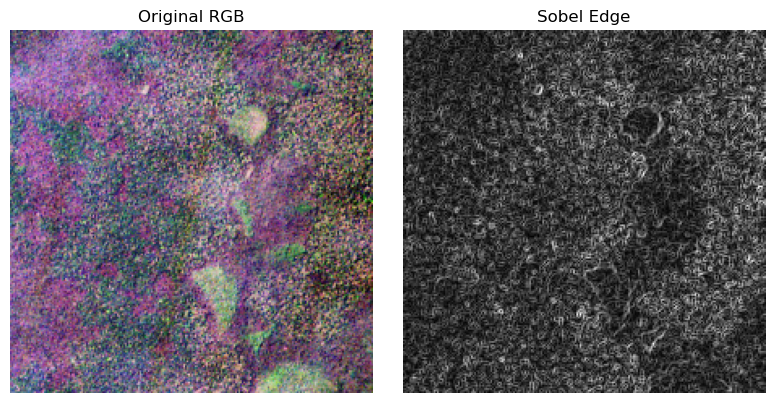

True: healthy    →    Predicted: healthy


In [29]:


# 0) grab your validation dataset
dataset = val_loader.dataset

# 1) determine your two class names
#    if your dataset has a `.classes` attribute, use that; otherwise define manually:
try:
    class_names = dataset.classes
    assert len(class_names) == 2
except Exception:
    class_names = ['healthy', 'deforested']

# 2) pick a random sample
idx = random.randint(0, len(dataset) - 1)
img_tensor, true_label = dataset[idx]   # shape [5, H, W]

# 3) prepare the first 3 bands for display
rgb = img_tensor[:3]  
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
inv_norm = Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std =[1/s   for s   in std]
)
rgb_disp = (inv_norm(rgb)
            .permute(1, 2, 0)  # [H, W, 3]
            .cpu()
            .clamp(0, 1)
            .numpy())

# 4) compute Sobel edge map
gray = rgb2gray(rgb_disp)
edge = sobel(gray)

# 5) run the full 5-channel tensor through your model
model.eval()
with torch.no_grad():
    batch = img_tensor.unsqueeze(0).to(device)  # [1,5,H,W]
    logits = model(batch)
    pred_idx = logits.argmax(dim=1).item()

# 6) plot & print
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(rgb_disp)
ax1.set_title("Original RGB")
ax1.axis("off")

ax2.imshow(edge, cmap="gray")
ax2.set_title("Sobel Edge")
ax2.axis("off")

plt.tight_layout()
plt.show()

print(f"True: {class_names[true_label]}    →    Predicted: {class_names[pred_idx]}")
